# AIS 피처 ablation — HDG 기여도 정량 검증

수중 음향 선박 인식 / **Task 1 선종 4-class (Macro F1)**

> **기본 실행 = PART 2(LGBM AIS-only)만** — HDG 기여를 몇 분 내 판정(GPU 불필요).
> 신호가 보이면 셀 2의 `RUN_ACOUSTIC=True` 로 PART 1(음향 CNN)을 추가 실행.

- **PART 2 — AIS-only LightGBM ablation** (기본 실행): 피처 종류별 HDG 순수 기여도
  - 모델 C (4-d, A 인코딩) / 모델 D (7-d, B 인코딩) / 모델 Dp = D' (raw, LGBM NaN 처리)
- **PART 1 — 음향 융합 ablation** (`RUN_ACOUSTIC=True` 시): EfficientNet-B0 + AIS late-fusion
  - 모델 A (4-d): `[sog_norm, cog_sin, cog_cos, sog_zero]` (HDG 제외)
  - 모델 B (7-d): `[sog_norm, cog_sin, cog_cos, hdg_sin, hdg_cos, cog_missing, hdg_missing]`

> 필요 패키지: lightgbm, pandas, scikit-learn, numpy (+ PART1 시 torch, timm, librosa, matplotlib, shap).
> mel 캐시(PART1): 기본은 기존 `data/spec_cache`(fmax=16000) 재사용. 셀 2 `REUSE_EXISTING_CACHE` 참고.

In [2]:
import os, time, math, random, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    except Exception:
        pass
seed_everything(SEED)

# ---- 경로 (EDA와 동일: notebooks/ 에서 열면 ../data, 루트에서 열면 data) ----
BASE = '../data' if os.path.isdir('../data/train') else 'data'
TRAIN_CSV   = BASE + '/train/train.csv'
TRAIN_AUDIO = BASE + '/train/audio'
OOF_DIR     = 'oof'; os.makedirs(OOF_DIR, exist_ok=True)

CLASSES = ['A_SmallWorking', 'B_MotorBoat', 'C_Passenger', 'D_LargeShip']
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

# ---- 실행 범위 토글 ----
# RUN_ACOUSTIC=False -> PART2(LGBM AIS-only)만 실행. HDG 기여를 몇 분 내 판정(GPU 불필요).
# True 로 켜면 PART1(음향 CNN A/B) 까지 실행.
RUN_ACOUSTIC = True

# ---- 음향 파라미터 (PART1에서만 사용) ----
SR=32000; DURATION=5.0; N_MELS=128; N_FFT=2048; HOP=512; FMIN=50

# ---- mel 캐시 선택 (PART1에서만 사용) ----
# 서버 data/spec_cache 에 train 캐시 존재(repo src/data/mel.py: fmax=16000, [0,1] 정규화).
# 노트북은 로드시 클립별 z-score 적용 -> [0,1] vs dB(아핀 변환) 차이는 무해. fmax 만 캐시값과 일치시킬 것.
REUSE_EXISTING_CACHE = True
if REUSE_EXISTING_CACHE:
    CACHE_DIR = BASE + '/spec_cache'        # 기존 train 캐시 재사용 (재변환 없음)
    FMAX = 16000
else:
    CACHE_DIR = BASE + '/spec_cache_f8000'  # 신규 전용 캐시
    FMAX = 8000                             # 첫 실행 시 35k 재변환(수십분)

# ---- 학습 하이퍼파라미터 (A/B 공통. 변경 가능 지점은 인코딩과 d_in 뿐) ----
N_FOLDS=5; EPOCHS=8; BATCH=128; LR=1e-3; WD=1e-4; NUM_WORKERS=0  # A100 1g: BATCH↑, worker=0(preload)
TIME_MASK=20; FREQ_MASK=20; MIXUP_ALPHA=0.4
EMBED_AC=512; AIS_HID=64; AIS_OUT=32; FUSION_HID=128
AUG_SEED=12345
FOLDS_ACOUSTIC=[0]   # PART1 fold. 시간되면 [0,1,2]. 전체 OOF는 list(range(5))

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '| torch', torch.__version__)
print('RUN_ACOUSTIC =', RUN_ACOUSTIC, '| CACHE_DIR =', CACHE_DIR, '| FMAX =', FMAX)
if RUN_ACOUSTIC and DEVICE.type == 'cpu':
    print('경고: GPU 미감지인데 RUN_ACOUSTIC=True. PART1은 매우 느리다.')

device: cuda | torch 2.5.1+cu121
RUN_ACOUSTIC = True | CACHE_DIR = ../data/spec_cache | FMAX = 16000


## 1. 데이터 로드 · 센티넬 검증 · fold 분할

In [3]:
df = pd.read_csv(TRAIN_CSV)
print('shape:', df.shape, '| 컬럼:', list(df.columns))

y = df['ship_type'].map(CLS2IDX).values
groups = df['ship_id'].values
N = len(df)
sog = df['sog'].astype(float).values
cog = df['cog'].astype(float).values
hdg = df['true_heading'].astype(float).values

# 센티넬/결측 재확인 (EDA 정합성)
print('SOG==0  :', int((sog==0).sum()),   '(%.2f%%)' % ((sog==0).mean()*100))
print('COG==360:', int((cog==360).sum()), '(%.2f%%)' % ((cog==360).mean()*100))
print('HDG==0  :', int((hdg==0).sum()),   '(%.2f%%)' % ((hdg==0).mean()*100))
print('HDG==511:', int((hdg==511).sum()), '| HDG>360:', int((hdg>360).sum()))

from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(sgkf.split(df, y, groups))

print()
print('=== fold별 val 클래스 클립수 (분할 균형 확인) ===')
for fi, (tr, va) in enumerate(folds):
    cnt = np.bincount(y[va], minlength=4)
    line = '  '.join('%s=%d' % (CLASSES[k], cnt[k]) for k in range(4))
    print('fold%d  val=%6d   %s' % (fi, len(va), line))

shape: (35183, 7) | 컬럼: ['filename', 'ship_id', 'ship_type', 'ais_timestamp', 'sog', 'cog', 'true_heading']
SOG==0  : 22411 (63.70%)
COG==360: 2238 (6.36%)
HDG==0  : 19615 (55.75%)
HDG==511: 0 | HDG>360: 2

=== fold별 val 클래스 클립수 (분할 균형 확인) ===
fold0  val=  6150   A_SmallWorking=3892  B_MotorBoat=557  C_Passenger=450  D_LargeShip=1251
fold1  val=  7957   A_SmallWorking=4456  B_MotorBoat=1015  C_Passenger=842  D_LargeShip=1644
fold2  val=  5960   A_SmallWorking=2952  B_MotorBoat=1164  C_Passenger=472  D_LargeShip=1372
fold3  val=  7062   A_SmallWorking=3573  B_MotorBoat=2089  C_Passenger=548  D_LargeShip=852
fold4  val=  8054   A_SmallWorking=4425  B_MotorBoat=1137  C_Passenger=1448  D_LargeShip=1044


## 2. AIS 인코딩 함수 (A/B 음향융합용, C/D/Dp AIS-only용)

In [4]:
def sog_logclip(s):
    return np.log1p(np.clip(s, 0, 30))

def fit_sog_stats(idx):
    # SOG 표준화 통계는 train fold에서만 계산 (누수 방지)
    v = sog_logclip(sog[idx])
    return float(v.mean()), float(v.std() + 1e-6)

def encode_A(idx, stats):
    m, s = stats
    sn = (sog_logclip(sog[idx]) - m) / s
    sz = (sog[idx] == 0).astype(np.float32)
    r = np.deg2rad(cog[idx]); csin = np.sin(r); ccos = np.cos(r)
    mask = (sog[idx] == 0)               # 정지 시 cog 무의미 -> 0 마스킹
    csin[mask] = 0; ccos[mask] = 0
    return np.stack([sn, csin, ccos, sz], axis=1).astype(np.float32)

def encode_B(idx, stats):
    m, s = stats
    sn = (sog_logclip(sog[idx]) - m) / s
    rc = np.deg2rad(cog[idx]); rh = np.deg2rad(hdg[idx])
    csin = np.sin(rc); ccos = np.cos(rc); hsin = np.sin(rh); hcos = np.cos(rh)
    cmiss = (cog[idx] == 360); hmiss = (hdg[idx] == 0) | (hdg[idx] > 360)
    csin[cmiss] = 0; ccos[cmiss] = 0; hsin[hmiss] = 0; hcos[hmiss] = 0
    return np.stack([sn, csin, ccos, hsin, hcos,
                     cmiss.astype(np.float32), hmiss.astype(np.float32)], axis=1).astype(np.float32)

def encode_C(idx):
    sc = np.clip(sog[idx], 0, 30).astype(np.float32)
    sz = (sog[idx] == 0).astype(np.float32)
    r = np.deg2rad(cog[idx]); csin = np.sin(r); ccos = np.cos(r)
    mask = (sog[idx] == 0); csin[mask] = 0; ccos[mask] = 0
    return np.stack([sc, csin, ccos, sz], axis=1).astype(np.float32)

def encode_D(idx):
    sc = np.clip(sog[idx], 0, 30).astype(np.float32)
    rc = np.deg2rad(cog[idx]); rh = np.deg2rad(hdg[idx])
    csin = np.sin(rc); ccos = np.cos(rc); hsin = np.sin(rh); hcos = np.cos(rh)
    cmiss = (cog[idx] == 360); hmiss = (hdg[idx] == 0) | (hdg[idx] > 360)
    csin[cmiss] = 0; ccos[cmiss] = 0; hsin[hmiss] = 0; hcos[hmiss] = 0
    return np.stack([sc, csin, ccos, hsin, hcos,
                     cmiss.astype(np.float32), hmiss.astype(np.float32)], axis=1).astype(np.float32)

def encode_Dp(idx):
    sr_ = sog[idx].astype(np.float32).copy()
    cr_ = cog[idx].astype(np.float32).copy()
    hr_ = hdg[idx].astype(np.float32).copy()
    cr_[cog[idx] == 360] = np.nan
    hr_[(hdg[idx] == 0) | (hdg[idx] > 360)] = np.nan
    return np.stack([sr_, cr_, hr_], axis=1).astype(np.float32)

FEAT_C  = ['sog_clip', 'cog_sin', 'cog_cos', 'sog_zero']
FEAT_D  = ['sog_clip', 'cog_sin', 'cog_cos', 'hdg_sin', 'hdg_cos', 'cog_missing', 'hdg_missing']
FEAT_Dp = ['sog_raw', 'cog_raw', 'hdg_raw']
print('인코딩 함수 준비 완료')

인코딩 함수 준비 완료


## PART 1 — 음향 융합 ablation (A 4-d vs B 7-d)

> 이 섹션(셀 8~12)은 `RUN_ACOUSTIC=True` 일 때만 실제 실행된다. 기본(False)에서는 모두 건너뛴다.

### mel 캐시 확인
- `REUSE_EXISTING_CACHE=True`(기본): 기존 `data/spec_cache`(fmax=16000, [0,1] 정규화) 재사용 → 재변환 없음.
- `False`: `spec_cache_f8000`에 fmax=8000 신규 빌드.
- A/B는 같은 캐시를 공유 → Δ_fusion 결론은 fmax와 무관하게 유효(절대 F1만 달라짐).

In [5]:
def wav_to_logmel(path):
    import librosa
    wav, _ = librosa.load(path, sr=SR, duration=DURATION, mono=True)
    tlen = int(SR * DURATION)
    if len(wav) < tlen:
        wav = np.pad(wav, (0, tlen - len(wav)))
    else:
        wav = wav[:tlen]
    mel = librosa.feature.melspectrogram(y=wav, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                                         hop_length=HOP, fmin=FMIN, fmax=FMAX)
    logmel = librosa.power_to_db(mel, ref=np.max)   # dB. 정규화는 로드시 클립별로.
    return logmel.astype(np.float32)

def build_cache(filenames, audio_dir, cache_dir):
    os.makedirs(cache_dir, exist_ok=True)
    todo = [f for f in filenames
            if not os.path.exists(os.path.join(cache_dir, f[:-4] + '.npy'))]
    print('cache:', len(filenames), '개 중 변환필요', len(todo), '->', cache_dir)
    if not todo:
        print('  -> 모두 존재. 재변환 없음.')
        return
    if REUSE_EXISTING_CACHE:
        # 재사용 모드인데 일부 누락: 다른 fmax로 누락분만 구우면 캐시가 섞임 -> 빌드 생략하고 경고만.
        print('  [중단] REUSE 모드에서 %d개 누락. 누락분을 fmax=%d로 새로 구우면 캐시가 혼용됨.' % (len(todo), FMAX))
        print('         기존 파이프라인으로 누락분을 채우거나, REUSE_EXISTING_CACHE=False 로 전체 재빌드할 것.')
        raise SystemExit('cache 누락 - 위 안내 참고')
    from tqdm import tqdm
    def one(f):
        try:
            np.save(os.path.join(cache_dir, f[:-4] + '.npy'),
                    wav_to_logmel(os.path.join(audio_dir, f)))
        except Exception as e:
            print('실패', f, e)
    try:
        from joblib import Parallel, delayed
        Parallel(n_jobs=-1)(delayed(one)(f) for f in tqdm(todo))
    except Exception:
        for f in tqdm(todo):
            one(f)

if not RUN_ACOUSTIC:
    print('mel 캐시 단계 건너뜀 — RUN_ACOUSTIC=False (LGBM은 캐시 불필요)')
else:
    build_cache(df['filename'].tolist(), TRAIN_AUDIO, CACHE_DIR)
    # 캐시 정합성 점검: shape(n_mels, T)와 값 범위 1개 확인
    import glob
    _all = sorted(glob.glob(os.path.join(CACHE_DIR, '*.npy')))
    # packed_all.npy(3-d)는 건너뛰고 개별 파일 우선, 없으면 packed 슬라이스로 확인
    _indiv = [f for f in _all if 'packed' not in os.path.basename(f)]
    if _indiv:
        _s = np.load(_indiv[0])
        _fname = os.path.basename(_indiv[0])
    elif _all:
        _s = np.load(_all[0], mmap_mode='r')[0]   # packed: 첫 샘플만 슬라이스
        _fname = os.path.basename(_all[0]) + '[0]'
    else:
        _s = None; _fname = None
    if _s is not None:
        print('샘플 spec:', _fname, '| shape=', _s.shape,
              '| min=%.3f max=%.3f' % (float(_s.min()), float(_s.max())))
        assert _s.shape[0] == N_MELS, 'n_mels 불일치: 캐시 %d vs 설정 %d' % (_s.shape[0], N_MELS)
        print('  n_mels=%d 일치. (z-score 정규화하므로 [0,1]이든 dB든 무해)' % N_MELS)

cache: 35183 개 중 변환필요 0 -> ../data/spec_cache
  -> 모두 존재. 재변환 없음.
샘플 spec: task1_test_000001.npy | shape= (128, 313) | min=0.000 max=1.000
  n_mels=128 일치. (z-score 정규화하므로 [0,1]이든 dB든 무해)


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as Fn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

class AisAudioDS(Dataset):
    def __init__(self, idx, ais, desc='ds'):
        self.idx = np.asarray(idx)
        self.ais = ais.astype(np.float32)
        files = df['filename'].values
        # 전체 스펙을 RAM에 preload — 35k × 0.16MB ≈ 5.6GB (24GB 환경)
        # disk I/O를 init 1회로 끝내 epoch 루프에서 병목 제거
        self._cache = []
        for i in tqdm(self.idx, desc='preload[%s]' % desc, ncols=80, leave=False):
            sp = np.load(os.path.join(CACHE_DIR, files[i][:-4] + '.npy'))
            self._cache.append(((sp - sp.mean()) / (sp.std() + 1e-6)).astype(np.float32))

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        x = torch.from_numpy(self._cache[i].copy()).unsqueeze(0)
        a = torch.from_numpy(self.ais[i])
        return x, a, int(y[self.idx[i]])

def make_loader(idx, ais, shuffle, desc='ds'):
    g = torch.Generator(); g.manual_seed(SEED)        # 셔플 순서 고정 -> A/B 동일
    return DataLoader(AisAudioDS(idx, ais, desc=desc), batch_size=BATCH, shuffle=shuffle,
                      num_workers=0,                  # preload 환경: worker 불필요
                      pin_memory=(DEVICE.type == 'cuda'),
                      generator=g, drop_last=False)

def spec_augment(x, gen):
    b_, _, M, T = x.shape
    x = x.clone()
    for b in range(b_):
        fl = int(torch.randint(1, FREQ_MASK + 1, (1,), generator=gen).item())
        f0 = int(torch.randint(0, max(1, M - fl), (1,), generator=gen).item())
        x[b, :, f0:f0 + fl, :] = 0
        tl = int(torch.randint(1, TIME_MASK + 1, (1,), generator=gen).item())
        t0 = int(torch.randint(0, max(1, T - tl), (1,), generator=gen).item())
        x[b, :, :, t0:t0 + tl] = 0
    return x

def mixup(x, lab, gen, nprng, alpha=MIXUP_ALPHA):
    lam = float(nprng.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), generator=gen)
    xm = lam * x + (1 - lam) * x[perm]
    return xm, lab, lab[perm], lam

# augmentation 전용 RNG(gen/nprng)는 모델과 독립 -> d_in 차이가 aug를 바꾸지 않음(A/B 동일)
print('dataset / loader / augment 준비 완료')


dataset / loader / augment 준비 완료


In [7]:
class FusionNet(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        import timm
        self.backbone = timm.create_model('tf_efficientnet_b0_ns', pretrained=True,
                                          num_classes=0, in_chans=1, global_pool='avg')
        bf = self.backbone.num_features
        self.ac = nn.Sequential(nn.Linear(bf, EMBED_AC), nn.BatchNorm1d(EMBED_AC), nn.GELU())
        self.fusion = nn.Sequential(nn.Linear(EMBED_AC + AIS_OUT, FUSION_HID), nn.ReLU(),
                                    nn.Dropout(0.3), nn.Linear(FUSION_HID, 4))
        # ais 브랜치를 마지막에 생성 -> 백본/ac/fusion init RNG를 A/B 동일하게 유지
        self.ais = nn.Sequential(nn.Linear(d_in, AIS_HID), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(AIS_HID, AIS_OUT))
    def forward(self, x, a):
        h = self.ac(self.backbone(x))
        z = self.ais(a)
        return self.fusion(torch.cat([h, z], dim=1))

from sklearn.metrics import f1_score

def warmup_cosine(step, total, warm):
    if step < warm:
        return (step + 1) / max(1, warm)
    p = (step - warm) / max(1, total - warm)
    return 0.5 * (1 + math.cos(math.pi * p))

def train_one_fold(d_in, tr_idx, va_idx, ais_tr, ais_va, class_w, tag):
    seed_everything(SEED)                  # 모델 init 직전 시드 고정
    model = FusionNet(d_in).to(DEVICE)
    model = torch.compile(model)          # A100: ~15% 추가 단축
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))
    cw = torch.tensor(class_w, dtype=torch.float32, device=DEVICE)
    tr_loader = make_loader(tr_idx, ais_tr, True,  desc=tag+'/tr')
    va_loader = make_loader(va_idx, ais_va, False, desc=tag+'/va')
    total = len(tr_loader) * EPOCHS; warm = len(tr_loader)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: warmup_cosine(s, total, warm))
    gen = torch.Generator(); nprng = np.random.RandomState()
    best = -1.0; best_ep = -1; best_pc = None; best_oof = None; hist = []
    t0 = time.time()
    ep_bar = tqdm(range(EPOCHS), desc='[%s]' % tag, ncols=90)
    for ep in ep_bar:
        model.train(); run_loss = 0.0
        bat_bar = tqdm(tr_loader, desc='  ep%d/%d' % (ep+1, EPOCHS),
                       ncols=90, leave=False)
        for bi, (x, a, lab) in enumerate(bat_bar):
            key = AUG_SEED + ep * 100000 + bi
            gen.manual_seed(key); nprng.seed((key + 777) % (2 ** 31))
            x = spec_augment(x, gen)
            x, ya, yb, lam = mixup(x, lab, gen, nprng)
            x = x.to(DEVICE); a = a.to(DEVICE); ya = ya.to(DEVICE); yb = yb.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                out = model(x, a)
                loss = (lam * Fn.cross_entropy(out, ya, weight=cw)
                        + (1 - lam) * Fn.cross_entropy(out, yb, weight=cw))
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()
            run_loss += loss.item()
            bat_bar.set_postfix(loss='%.4f' % (run_loss / (bi + 1)))
        model.eval(); P = []; YL = []
        with torch.no_grad():
            for x, a, lab in va_loader:
                x = x.to(DEVICE); a = a.to(DEVICE)
                with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                    out = model(x, a)
                P.append(torch.softmax(out, 1).float().cpu().numpy()); YL.append(lab.numpy())
        P = np.concatenate(P); YL = np.concatenate(YL)
        f1 = f1_score(YL, P.argmax(1), average='macro')
        pc = f1_score(YL, P.argmax(1), average=None, labels=[0, 1, 2, 3])
        hist.append(float(f1))
        star = ' *' if f1 > best else ''
        ep_bar.set_postfix(f1='%.4f' % f1, best='%.4f' % max(best, f1))
        if f1 > best:
            best = f1; best_ep = ep + 1; best_pc = pc; best_oof = P.copy()
        tqdm.write('[%s] ep%d/%d  loss=%.4f  val_F1=%.4f%s' % (
            tag, ep+1, EPOCHS, run_loss / len(tr_loader), f1, star))
    mins = (time.time() - t0) / 60
    tqdm.write('[%s] done best MacroF1=%.4f @ep%d  (%.1f분)' % (tag, best, best_ep, mins))
    return dict(hist=hist, best=float(best), best_ep=best_ep, pc=best_pc,
                oof=best_oof, va=va_idx, minutes=mins)


In [8]:
from tqdm.auto import tqdm

res_ac = {'A': [], 'B': []}
oof_A = oof_B = None

if not RUN_ACOUSTIC:
    print('PART 1(음향 융합 A/B) 건너뜀 — RUN_ACOUSTIC=False. PART 2(LGBM)만 실행.')
else:
    oof_A = np.full((N, 4), np.nan, np.float32)
    oof_B = np.full((N, 4), np.nan, np.float32)
    fold_bar = tqdm(FOLDS_ACOUSTIC, desc='PART1 folds', ncols=60)
    for fi in fold_bar:
        fold_bar.set_postfix(fold=fi)
        tr_idx, va_idx = folds[fi]
        stats = fit_sog_stats(tr_idx)                       # train fold SOG 통계 (A/B 공유)
        cnt = np.bincount(y[tr_idx], minlength=4).astype(np.float64)
        cw = 1.0 / cnt; cw = cw / cw.sum() * 4              # 1/클립수, 정규화(평균 1)
        tqdm.write('--- fold%d | sog_stats=(%.3f, %.3f) | class_w=%s ---'
              % (fi, stats[0], stats[1], np.round(cw, 3)))
        rA = train_one_fold(4, tr_idx, va_idx, encode_A(tr_idx, stats), encode_A(va_idx, stats), cw, 'A.f%d' % fi)
        rB = train_one_fold(7, tr_idx, va_idx, encode_B(tr_idx, stats), encode_B(va_idx, stats), cw, 'B.f%d' % fi)
        rA['fold'] = fi; rB['fold'] = fi
        res_ac['A'].append(rA); res_ac['B'].append(rB)
        oof_A[va_idx] = rA['oof']; oof_B[va_idx] = rB['oof']
        tqdm.write('fold%d 완료 | A=%.4f  B=%.4f' % (fi, rA['best'], rB['best']))


PART1 folds:   0%|            | 0/1 [00:00<?, ?it/s, fold=0]

--- fold0 | sog_stats=(0.348, 0.781) | class_w=[0.344 0.979 1.599 1.078] ---











































































































































































































































































































































































































































































PART1 folds:   0%|            | 0/1 [09:16<?, ?it/s, fold=0]                              

[A.f0] ep1/8  loss=1.3225  val_F1=0.2226 *











































































































































































































































































































































































































































































PART1 folds:   0%|            | 0/1 [11:59<?, ?it/s, fold=0]                              

...

[B.f0] ep6/8  loss=1.1588  val_F1=0.3808











































































































































































































































































































































































































































































PART1 folds:   0%|            | 0/1 [59:10<?, ?it/s, fold=0]                              

[B.f0] ep7/8  loss=1.1381  val_F1=0.3794











































































































































































































































































































































































































































































[B.f0]: 100%|██████████████████████| 8/8 [24:10<00:00, 181.36s/it, best=0.4087, f1=0.3680]
PART1 folds: 100%|█| 1/1 [1:01:50<00:00, 3710.58s/it, fold=0

[B.f0] ep8/8  loss=1.1322  val_F1=0.3680
[B.f0] done best MacroF1=0.4087 @ep5  (24.2분)
fold0 완료 | A=0.3210  B=0.4087


| 모델 | fold | best MacroF1 | best ep | F1_A | F1_B | F1_C | F1_D | 시간 |
|------|------|--------------|---------|------|------|------|------|------|
| A 4d | 0 | 0.3210 | 4 | 0.3589 | 0.1361 | 0.2726 | 0.5167 | 23.2분 |
| B 7d | 0 | 0.4087 | 5 | 0.5096 | 0.1766 | 0.3190 | 0.6297 | 24.2분 |


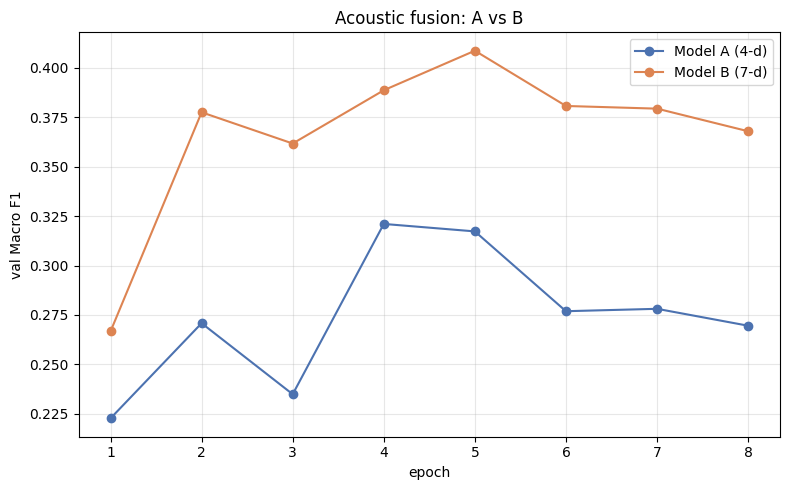

코멘트: 클래스 A_SmallWorking 에서 차이 최대 (B-A ΔF1=+0.1508).
클래스별 B-A ΔF1: {'A_SmallWorking': np.float64(0.1508), 'B_MotorBoat': np.float64(0.0406), 'C_Passenger': np.float64(0.0465), 'D_LargeShip': np.float64(0.1129)}


In [9]:
def agg(rs):
    best = float(np.mean([r['best'] for r in rs]))
    ep = int(round(np.mean([r['best_ep'] for r in rs])))
    pc = np.mean([r['pc'] for r in rs], axis=0)
    mins = float(np.sum([r['minutes'] for r in rs]))
    return best, ep, pc, mins

if not res_ac['A']:
    print('PART 1(음향) 미실행 — 표/곡선 생략 (RUN_ACOUSTIC=False)')
else:
    import matplotlib.pyplot as plt
    print('| 모델 | fold | best MacroF1 | best ep | F1_A | F1_B | F1_C | F1_D | 시간 |')
    print('|------|------|--------------|---------|------|------|------|------|------|')
    for tag in ['A', 'B']:
        dlabel = '4d' if tag == 'A' else '7d'
        for r in res_ac[tag]:
            pc = r['pc']
            print('| %s %s | %d | %.4f | %d | %.4f | %.4f | %.4f | %.4f | %.1f분 |'
                  % (tag, dlabel, r['fold'], r['best'], r['best_ep'],
                     pc[0], pc[1], pc[2], pc[3], r['minutes']))

    plt.figure(figsize=(8, 5))
    for tag, col in [('A', '#4C72B0'), ('B', '#DD8452')]:
        h = np.mean([r['hist'] for r in res_ac[tag]], axis=0)
        lab = 'Model A (4-d)' if tag == 'A' else 'Model B (7-d)'
        plt.plot(range(1, len(h) + 1), h, marker='o', color=col, label=lab)
    plt.xlabel('epoch'); plt.ylabel('val Macro F1'); plt.title('Acoustic fusion: A vs B')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    pcA = agg(res_ac['A'])[2]; pcB = agg(res_ac['B'])[2]
    d = pcB - pcA; k = int(np.argmax(np.abs(d)))
    print('코멘트: 클래스 %s 에서 차이 최대 (B-A ΔF1=%+.4f).' % (CLASSES[k], d[k]))
    print('클래스별 B-A ΔF1:', dict(zip(CLASSES, np.round(d, 4))))

## PART 2 — AIS-only LightGBM ablation (C / D / Dp=D')

In [10]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

ALL = np.arange(N)
X    = {'C 4d': encode_C(ALL), 'D 7d': encode_D(ALL), 'Dp raw': encode_Dp(ALL)}
FEAT = {'C 4d': FEAT_C,        'D 7d': FEAT_D,        'Dp raw': FEAT_Dp}

# colsample_bytree=feature_fraction, subsample=bagging_fraction, subsample_freq=bagging_freq
LGB = dict(objective='multiclass', num_class=4, n_estimators=2000, learning_rate=0.05,
           num_leaves=31, min_child_samples=20, colsample_bytree=0.9, subsample=0.8,
           subsample_freq=5, class_weight='balanced', random_state=SEED, n_jobs=-1)

def run_lgbm(name):
    Xf = X[name]; oof = np.zeros((N, 4), np.float32)
    imp = np.zeros(Xf.shape[1]); last = None; t0 = time.time()
    for tr, va in folds:
        clf = LGBMClassifier(**LGB)
        clf.fit(Xf[tr], y[tr], eval_set=[(Xf[va], y[va])], eval_metric='multi_logloss',
                callbacks=[early_stopping(50), log_evaluation(0)])
        oof[va] = clf.predict_proba(Xf[va])
        imp += clf.booster_.feature_importance('gain'); last = clf
    f1 = f1_score(y, oof.argmax(1), average='macro')
    pc = f1_score(y, oof.argmax(1), average=None, labels=[0, 1, 2, 3])
    mins = (time.time() - t0) / 60
    print('[%s] OOF MacroF1=%.4f  (%.1f분)' % (name, f1, mins))
    return dict(name=name, oof=oof, f1=float(f1), pc=pc, imp=imp / N_FOLDS,
                feat=FEAT[name], minutes=mins, model=last)

rC = run_lgbm('C 4d'); rD = run_lgbm('D 7d'); rDp = run_lgbm('Dp raw')

print()
print('| 모델 | OOF MacroF1 | F1_A | F1_B | F1_C | F1_D | 시간 |')
print('|--------|-------------|------|------|------|------|------|')
for r in [rC, rD, rDp]:
    pc = r['pc']
    print('| %-6s | %.4f | %.4f | %.4f | %.4f | %.4f | %.1f분 |'
          % (r['name'], r['f1'], pc[0], pc[1], pc[2], pc[3], r['minutes']))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 29033, number of used features: 4
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[59]	valid_0's multi_logloss: 1.1246
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 679
[LightGBM] [Info] Number of data points i

In [11]:
impD = rD['imp']; order = np.argsort(impD)[::-1]
print('=== Model D feature importance (gain, fold 평균) ===')
for j in order:
    print('  %-14s %12.1f' % (FEAT_D[j], impD[j]))

# SHAP summary (선택). shap 미설치/실패 시 건너뜀.
try:
    import shap
    samp = np.random.RandomState(SEED).choice(N, size=min(2000, N), replace=False)
    expl = shap.TreeExplainer(rD['model'])
    sv = expl.shap_values(X['D 7d'][samp])
    shap.summary_plot(sv, X['D 7d'][samp], feature_names=FEAT_D, show=True)
except Exception as e:
    print('SHAP 생략:', e)

=== Model D feature importance (gain, fold 평균) ===
  hdg_sin             81546.5
  sog_clip            62147.3
  hdg_cos             59673.2
  cog_cos             53503.0
  cog_sin             42192.0
  hdg_missing         36810.3
  cog_missing         10624.4
SHAP 생략: No module named 'shap'


## 최종 의사결정 · 앙상블 OOF 저장

- Δ_fusion = F1(B) − F1(A)  (융합 모델)
- Δ_aisonly = F1(D) − F1(C)  (AIS-only 모델)

In [12]:
# ===== AIS-only(LGBM) 결과로 HDG 판정 =====
fC = rC['f1']; fD = rD['f1']; fDp = rDp['f1']
d_aisonly = fD - fC
print('F1(C 4d)=%.4f  F1(D 7d)=%.4f  -> Δ_aisonly=%+.4f' % (fC, fD, d_aisonly))

if d_aisonly < 0.01:
    dec = 'HDG는 AIS 자체에서도 무의미(Δ_aisonly<0.01) -> 모델 A(4-d, HDG 제외) 확정. 음향 ablation 불필요.'
elif d_aisonly >= 0.02:
    dec = 'HDG 신호 뚜렷(Δ_aisonly>=0.02) -> 음향과 독립 기여 확인 위해 RUN_ACOUSTIC=True 로 PART1 추가 권장. AIS-only 보조모델은 D 채택.'
else:
    dec = '경계(0.01<=Δ_aisonly<0.02) -> 약한 신호. PART1(RUN_ACOUSTIC=True)로 확정 권장.'
print('판정(AIS-only):', dec)

# D vs D' (sin/cos 인코딩 vs raw NaN)
dd = abs(fD - fDp)
if dd < 0.005:
    print('D vs Dp: 차이 %.4f -> 더 단순한 Dp(raw NaN) 권장' % dd)
elif fDp > fD:
    print('Dp(raw) 우세 -> AIS-only 보조는 Dp, 음향 융합 인코딩은 D 유지(MLP는 NaN 불가)')
else:
    print('D 우세 -> D 인코딩 유지')

# ===== 음향 융합 결과가 있으면 병행 판정 =====
if res_ac['A']:
    fa = agg(res_ac['A'])[0]; fb = agg(res_ac['B'])[0]
    d_fusion = fb - fa
    print()
    print('F1(A)=%.4f  F1(B)=%.4f  -> Δ_fusion=%+.4f' % (fa, fb, d_fusion))
    if d_aisonly < 0.01:
        print('결정(융합): 모델 A(4-d) 확정.')
    elif d_aisonly >= 0.02 and d_fusion >= 0.01:
        print('결정(융합): HDG가 음향과 독립 -> 모델 B(7-d) 확정.')
    elif d_aisonly >= 0.02 and d_fusion < 0.005:
        print('결정(융합): HDG 신호는 있으나 음향이 이미 포착 -> 융합은 A, 앙상블 AIS-only는 D.')
    else:
        print('결정(융합): 경계 -> fold 1,2 추가 후 재판단.')
else:
    print()
    print('음향(PART1) 미실행: RUN_ACOUSTIC=False. 위 AIS-only 판정만 적용.')

# ===== 앙상블용 OOF 저장 =====
ais_chosen = rDp['oof'] if (abs(fD - fDp) < 0.005 or fDp > fD) else rD['oof']
np.save(OOF_DIR + '/oof_ais_lgbm.npy', ais_chosen)
print('저장: oof_ais_lgbm.npy  (%d/%d, LGBM 5-fold 전체)' % (N, N))
if res_ac['A']:
    chosen_ac = oof_B if (agg(res_ac['B'])[0] - agg(res_ac['A'])[0]) >= 0.01 else oof_A
    cov = int((~np.isnan(chosen_ac[:, 0])).sum())
    np.save(OOF_DIR + '/oof_acoustic_fusion.npy', chosen_ac)
    print('저장: oof_acoustic_fusion.npy  (%d/%d 채움)' % (cov, N))

F1(C 4d)=0.2982  F1(D 7d)=0.5069  -> Δ_aisonly=+0.2087
판정(AIS-only): HDG 신호 뚜렷(Δ_aisonly>=0.02) -> 음향과 독립 기여 확인 위해 RUN_ACOUSTIC=True 로 PART1 추가 권장. AIS-only 보조모델은 D 채택.
D vs Dp: 차이 0.0004 -> 더 단순한 Dp(raw NaN) 권장

F1(A)=0.3210  F1(B)=0.4087  -> Δ_fusion=+0.0877
결정(융합): HDG가 음향과 독립 -> 모델 B(7-d) 확정.
저장: oof_ais_lgbm.npy  (35183/35183, LGBM 5-fold 전체)
저장: oof_acoustic_fusion.npy  (6150/35183 채움)
